# Laboratorio 7
### Modelos de Regresión Logística
- Fabian Prado #23427
- Sofia Lopez #231929
- Jonathan Zacarias #231104
- repo: https://github.com/fabianpradod/lab7-mineria
---

## Contexto

En esta quinta entrega de consultoría para **SmartStay Advisors** aplicamos Regresión Logística tanto en su variante binaria (¿es cara una propiedad?) como multinomial (clasificación en *Económica*, *Intermedia* y *Cara*). Se mantienen los mismos conjuntos de entrenamiento y prueba de todas las entregas anteriores para garantizar comparaciones válidas entre algoritmos.

In [22]:
import time
import io
import pstats
import pyreadr
import warnings
import cProfile
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold, learning_curve
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score,
    roc_curve, auc, roc_auc_score
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
SEED = 42

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f9f9f9',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'font.family':      'sans-serif',
})

In [23]:
result = pyreadr.read_r('../data/listings.RData')
listings_df = list(result.values())[0]
print(f'Dataset cargado: {listings_df.shape[0]:,} filas x {listings_df.shape[1]} columnas')

def clean_price(val):
    if pd.isna(val): return np.nan
    cleaned = str(val).replace('$', '').replace(',', '').strip()
    if not cleaned: return np.nan
    try: return float(cleaned)
    except ValueError: return np.nan

def clean_rate(val):
    if pd.isna(val): return np.nan
    cleaned = str(val).replace('%', '').strip()
    if not cleaned or cleaned.upper() == 'N/A': return np.nan
    try: return float(cleaned) / 100
    except ValueError: return np.nan

def encode_bool(val):
    if pd.isna(val): return np.nan
    return 1 if str(val).strip().lower() in ('t', 'true', '1') else 0

listings_df['price']               = listings_df['price'].apply(clean_price)
listings_df['host_response_rate']  = listings_df['host_response_rate'].apply(clean_rate)
listings_df['host_acceptance_rate']= listings_df['host_acceptance_rate'].apply(clean_rate)

for col in ['host_is_superhost', 'host_has_profile_pic',
            'host_identity_verified', 'instant_bookable', 'has_availability']:
    if col in listings_df.columns:
        listings_df[col] = listings_df[col].apply(encode_bool)

resp_map = {'within an hour': 1, 'within a few hours': 2,
            'within a day': 3, 'a few days or more': 4}
if 'host_response_time' in listings_df.columns:
    listings_df['host_response_time'] = listings_df['host_response_time'].map(resp_map)

if 'estimated_occupancy_l365d' not in listings_df.columns and 'number_of_reviews_l365d' in listings_df.columns:
    listings_df['estimated_occupancy_l365d'] = listings_df['number_of_reviews_l365d'] * 3.5

priced_listings_df = listings_df.dropna(subset=['price']).copy()
priced_listings_df = priced_listings_df[priced_listings_df['price'] > 0].copy()
print(f'Registros con precio válido: {priced_listings_df.shape[0]:,}')

Dataset cargado: 171,748 filas x 80 columnas
Registros con precio válido: 76,246


In [24]:
NUMERIC_FEATURES = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'host_total_listings_count', 'calculated_host_listings_count',
    'host_response_rate', 'host_acceptance_rate', 'host_response_time',
    'minimum_nights', 'maximum_nights',
    'availability_365', 'estimated_occupancy_l365d',
    'host_is_superhost', 'host_has_profile_pic',
    'host_identity_verified', 'instant_bookable', 'has_availability'
]
CAT_FEATURES = ['room_type', 'city']

NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in priced_listings_df.columns]
CAT_FEATURES     = [c for c in CAT_FEATURES     if c in priced_listings_df.columns]

df_model = pd.get_dummies(
    priced_listings_df[NUMERIC_FEATURES + CAT_FEATURES + ['price']],
    columns=CAT_FEATURES, drop_first=False
)

X = df_model.drop(columns=['price'])
y = df_model['price']

# ── Variable categórica — mismos terciles de entregas anteriores ─────────────
q1 = priced_listings_df['price'].quantile(0.25)
q3 = priced_listings_df['price'].quantile(0.75)
print(f'Q1 (25%): ${q1:.2f}  |  Q3 (75%): ${q3:.2f}')

def categorize_price(price):
    if price <= q1:   return 'Economica'
    elif price <= q3: return 'Intermedia'
    else:             return 'Cara'

# ── Split 80/20 — SEED=42, idéntico a todas las entregas ────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f'Train: {X_train.shape[0]:,} filas  |  Test: {X_test.shape[0]:,} filas')

y_cat_train = y_train.apply(categorize_price)
y_cat_test  = y_test.apply(categorize_price)

print('\nDistribución en entrenamiento:')
print(y_cat_train.value_counts(normalize=True).map('{:.1%}'.format))

# ── Imputación y escalado ────────────────────────────────────────────────────
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

print('\nImputación y escalado aplicados correctamente.')

Q1 (25%): $120.00  |  Q3 (75%): $326.00
Train: 60,996 filas  |  Test: 15,250 filas

Distribución en entrenamiento:
price
Intermedia    49.6%
Economica     25.5%
Cara          24.9%
Name: proportion, dtype: str

Imputación y escalado aplicados correctamente.


---
## Variables dicotómicas por categoría de precio

Para aplicar regresión logística binaria se crean tres variables indicadoras a partir de la variable categórica de precio: una por cada segmento. Cada variable toma valor **1** si la propiedad pertenece a esa categoría y **0** en caso contrario.

In [25]:
# Variable dicotómica: Cara vs no-Cara
y_cara_train = (y_cat_train == 'Cara').astype(int)
y_cara_test  = (y_cat_test  == 'Cara').astype(int)

# Variable dicotómica: Intermedia vs no-Intermedia
y_media_train = (y_cat_train == 'Intermedia').astype(int)
y_media_test  = (y_cat_test  == 'Intermedia').astype(int)

# Variable dicotómica: Economica vs no-Economica
y_eco_train = (y_cat_train == 'Economica').astype(int)
y_eco_test  = (y_cat_test  == 'Economica').astype(int)

resumen = pd.DataFrame({
    'Variable':      ['Cara', 'Intermedia', 'Economica'],
    'Positivos train': [y_cara_train.sum(), y_media_train.sum(), y_eco_train.sum()],
    'Negativos train': [(y_cara_train==0).sum(), (y_media_train==0).sum(), (y_eco_train==0).sum()],
    'Positivos test':  [y_cara_test.sum(),  y_media_test.sum(),  y_eco_test.sum()],
    'Negativos test':  [(y_cara_test==0).sum(),  (y_media_test==0).sum(),  (y_eco_test==0).sum()],
})
print(resumen.to_string(index=False))

  Variable  Positivos train  Negativos train  Positivos test  Negativos test
      Cara            15218            45778            3836           11414
Intermedia            30254            30742            7628            7622
 Economica            15524            45472            3786           11464


---
## Modelo de Regresión Logística Binaria: ¿Es cara una propiedad?

Se entrena un modelo de regresión logística para predecir si una propiedad pertenece al segmento *Cara* (precio > $326). Se utiliza validación cruzada estratificada con 5 folds para estimar el desempeño de forma robusta, y se fija `random_state=42` para garantizar reproducibilidad. El umbral de decisión inicial es 0.5.

In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

lr_bin = LogisticRegression(max_iter=1000, random_state=SEED, solver='lbfgs')

cv_scores = cross_val_score(lr_bin, X_train_sc, y_cara_train,
                             cv=cv, scoring='accuracy')

print(f'Accuracy CV (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Scores por fold: {[f"{s:.4f}" for s in cv_scores]}')

# Entrenamos sobre todo el train para análisis de coeficientes
lr_bin.fit(X_train_sc, y_cara_train)
print('\nModelo entrenado correctamente.')

Accuracy CV (5-fold): 0.8358 ± 0.0023
Scores por fold: ['0.8332', '0.8334', '0.8373', '0.8357', '0.8392']

Modelo entrenado correctamente.


=== Top 15 variables por magnitud de coeficiente ===
                   Feature  Coeficiente  Odds Ratio
                 bathrooms     0.782937    2.187888
              accommodates     0.662354    1.939352
 estimated_occupancy_l365d    -0.544274    0.580263
        city_Austin, Texas    -0.404580    0.667257
 host_total_listings_count     0.338190    1.402407
     room_type_Shared room    -0.336755    0.714084
               city_Hawaii     0.318428    1.374965
                  bedrooms     0.284477    1.329067
     city_Washington, D.C.    -0.262498    0.769128
      room_type_Hotel room     0.225612    1.253090
         city_Rhode Island     0.220669    1.246911
            minimum_nights    -0.189704    0.827204
city_Boston, Massachusetts     0.188739    1.207726
        host_response_time     0.182678    1.200428
    city_Chicago, Illinois    -0.118226    0.888495


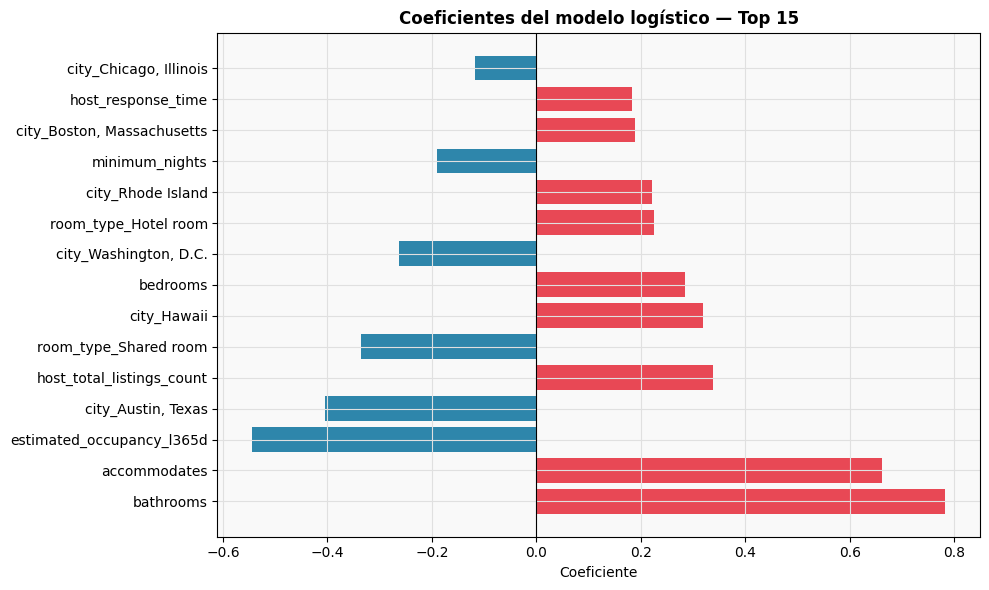

In [27]:
feature_names = X.columns.tolist()

coef_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coeficiente': lr_bin.coef_[0],
    'Odds Ratio':  np.exp(lr_bin.coef_[0])
}).sort_values('Coeficiente', key=abs, ascending=False)

print('=== Top 15 variables por magnitud de coeficiente ===')
print(coef_df.head(15).to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))
top15 = coef_df.head(15)
colors = ['#E84855' if c > 0 else '#2E86AB' for c in top15['Coeficiente']]
ax.barh(top15['Feature'], top15['Coeficiente'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes del modelo logístico — Top 15', fontweight='bold')
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

In [28]:
# VIF sobre una muestra para eficiencia computacional
sample_idx = np.random.RandomState(SEED).choice(X_train_sc.shape[0], size=5000, replace=False)
X_vif = pd.DataFrame(X_train_sc[sample_idx], columns=feature_names)

vif_data = pd.DataFrame({
    'Feature': feature_names,
    'VIF':     [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print('=== Factor de Inflación de Varianza (VIF) ===')
print(vif_data.to_string(index=False))
print('\nVIF > 10 indica multicolinealidad problemática.')
print(f'Variables con VIF > 10: {(vif_data["VIF"] > 10).sum()}')

=== Factor de Inflación de Varianza (VIF) ===
                       Feature      VIF
        city_Chicago, Illinois      inf
                   city_Hawaii      inf
         city_Washington, D.C.      inf
             city_Rhode Island      inf
    city_San Diego, California      inf
         room_type_Shared room      inf
            city_Austin, Texas      inf
    city_Boston, Massachusetts      inf
          room_type_Hotel room      inf
        room_type_Private room      inf
     room_type_Entire home/apt      inf
                      bedrooms 5.302809
                  accommodates 4.136078
                          beds 3.608780
                     bathrooms 2.758359
            host_response_time 2.003534
            host_response_rate 1.721776
calculated_host_listings_count 1.549481
          host_acceptance_rate 1.528642
     estimated_occupancy_l365d 1.411515
              instant_bookable 1.402075
     host_total_listings_count 1.343568
             host_is_superhost 1.2

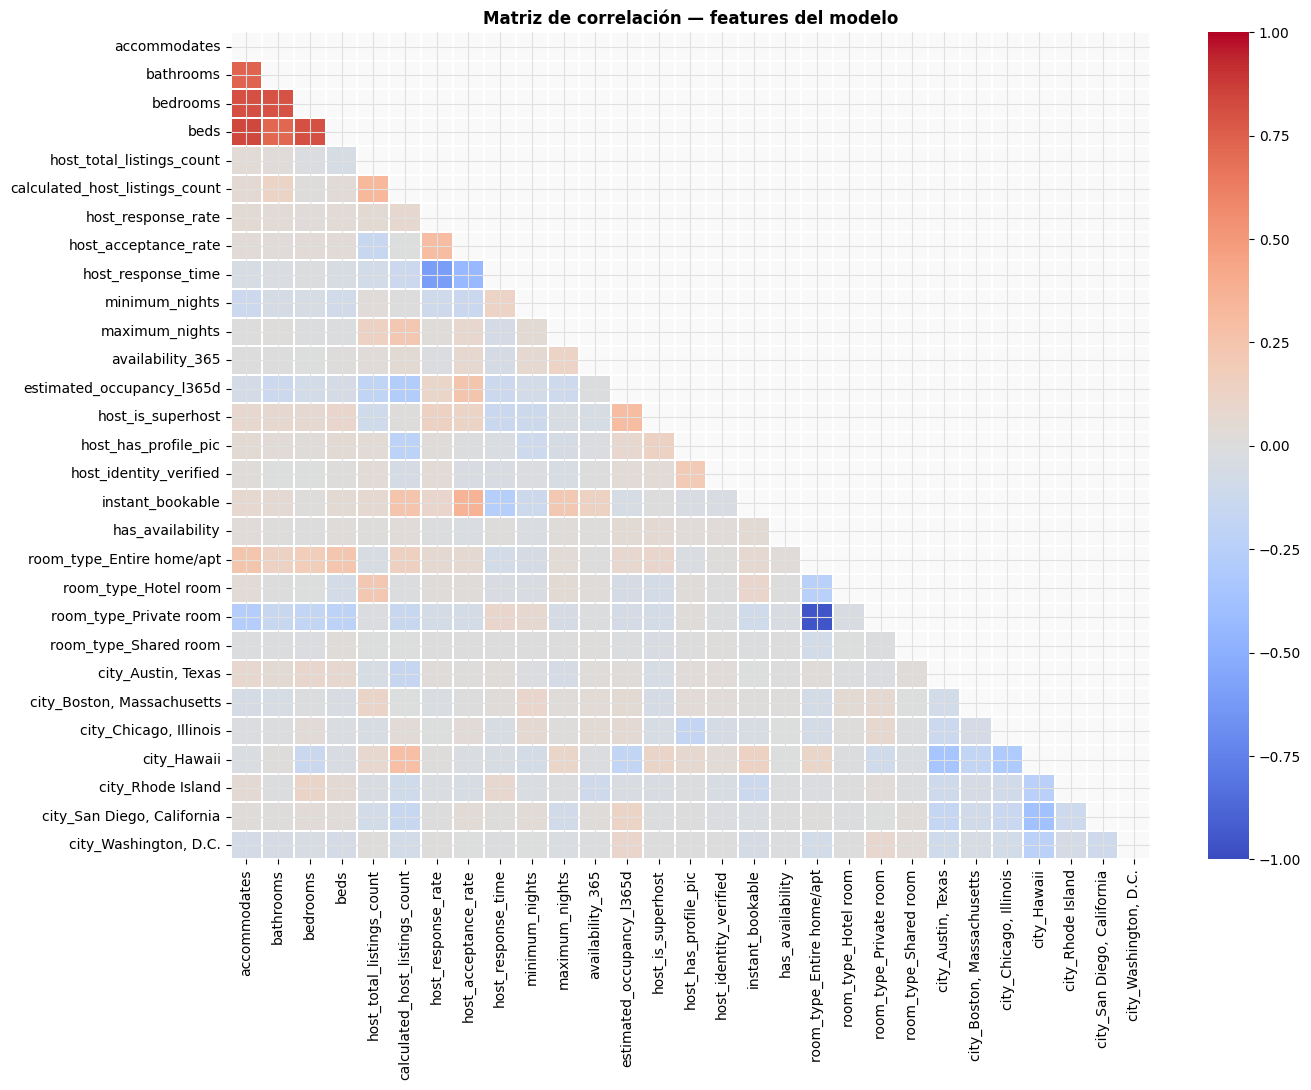


Pares con correlación |r| > 0.7:
  room_type_Entire home/apt — room_type_Private room: -0.955
  accommodates — beds: 0.838
  accommodates — bedrooms: 0.811
  bedrooms — beds: 0.809
  bathrooms — bedrooms: 0.799
  accommodates — bathrooms: 0.739
  bathrooms — beds: 0.723


In [29]:
X_sample = pd.DataFrame(X_train_sc[:3000], columns=feature_names)
corr = X_sample.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Matriz de correlación — features del modelo', fontweight='bold')
plt.tight_layout()
plt.show()

# Pares con correlación alta
high_corr = (corr.abs() > 0.7) & (corr != 1.0)
pairs = [(corr.columns[i], corr.columns[j], corr.iloc[i,j])
         for i in range(len(corr.columns))
         for j in range(i+1, len(corr.columns))
         if abs(corr.iloc[i,j]) > 0.7]

if pairs:
    print(f'\nPares con correlación |r| > 0.7:')
    for f1, f2, r in sorted(pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {f1} — {f2}: {r:.3f}')
else:
    print('\nNo se encontraron pares con correlación |r| > 0.7')

### Análisis del modelo logístico binario

**Desempeño con validación cruzada**

El modelo obtiene un Accuracy promedio de **83.58% ± 0.23%** en validación cruzada de 5 folds. La varianza entre folds es mínima (±0.23%), lo que indica que el modelo es estable y no depende del subconjunto particular de entrenamiento. Para una clasificación binaria donde la clase positiva (*Cara*) representa solo el 24.9% del conjunto de entrenamiento, este nivel de accuracy es una señal inicial positiva, aunque más adelante se deben evaluar métricas adicionales como precisión, recall y AUC que son más informativas ante desbalance de clases.

**Coeficientes e interpretación**

Las variables con mayor impacto positivo sobre la probabilidad de que una propiedad sea cara son **bathrooms** (coef = 0.783, OR = 2.19) y **accommodates** (coef = 0.662, OR = 1.94). En términos de odds ratios: cada unidad adicional de baños casi duplica las probabilidades de ser clasificada como cara, y cada persona adicional de capacidad las incrementa un 94%. Esto es consistente con la lógica del mercado — propiedades más grandes y con más baños justifican precios más altos.

Por el lado negativo, **estimated_occupancy_l365d** (coef = −0.544) y **city_Austin, Texas** (coef = −0.405) reducen la probabilidad de ser cara. El primer resultado es contraintuitivo a primera vista: propiedades con mayor ocupación estimada tienden a ser clasificadas como *no caras*. Esto puede explicarse porque las propiedades económicas e intermedias acumulan más reservas por su accesibilidad de precio, mientras que las caras tienen menor volumen de ocupación pero mayor ingreso por noche.

La variable **city_Hawaii** (coef = +0.318) eleva la probabilidad de ser cara, coherente con el mercado inmobiliario de Hawaii. Por otro lado, **city_Washington D.C.** y **city_Chicago** tienen coeficientes negativos, sugiriendo que en esas ciudades predominan propiedades de precio medio-bajo dentro del dataset.

**Multicolinealidad (VIF)**

Las 11 variables con VIF = ∞ corresponden a las dummies de `room_type` y `city`. Este resultado es esperado y se debe a la **trampa de variables dummy**: al incluir todas las categorías de una variable categórica sin eliminar una como referencia (`drop_first=False`), las columnas suman exactamente 1 por fila, creando dependencia lineal perfecta. La multicolinealidad en estos casos no afecta la capacidad predictiva del modelo, pero infla los errores estándar de los coeficientes individuales de esas variables. Para las variables numéricas continuas, los VIF oscilan entre 1.0 y 5.3, valores todos por debajo del umbral de 10 — indicando que entre ellas no hay multicolinealidad problemática.

**Correlación entre features**

El heatmap confirma lo que el VIF señaló: el bloque más correlacionado es el de tamaño físico de la propiedad. Los pares `accommodates–beds` (r = 0.838), `accommodates–bedrooms` (r = 0.811) y `bedrooms–beds` (r = 0.809) forman un cluster de alta colinealidad entre variables continuas. Esto tiene sentido: propiedades con más capacidad naturalmente tienen más camas y habitaciones. La correlación negativa fuerte entre `room_type_Entire home/apt` y `room_type_Private room` (r = −0.955) también es un artefacto de las dummies — es la misma trampa detectada por el VIF.

**Bondad de ajuste**

La estabilidad de los scores de CV (rango de 0.83 a 0.839) y la coherencia entre los coeficientes y el conocimiento del dominio sugieren que el modelo captura las señales principales del dataset. Sin embargo, el desbalance de clases (75% negativo vs 25% positivo) favorece artificialmente el accuracy — un clasificador que siempre diga "no cara" obtendría 75%. Por eso en el siguiente paso se evalúa el modelo sobre el conjunto de prueba con métricas completas.

---
## Evaluación del modelo en el conjunto de prueba

Con el modelo entrenado sobre el 80% de los datos, se evalúa su desempeño sobre el conjunto de prueba (15,250 registros) que no participó en el entrenamiento. El umbral de decisión es 0.5.

In [30]:
t0 = time.time()
y_pred_bin  = lr_bin.predict(X_test_sc)
y_prob_bin  = lr_bin.predict_proba(X_test_sc)[:, 1]
t_pred = time.time() - t0

acc_test  = accuracy_score(y_cara_test, y_pred_bin)
prec_test = precision_score(y_cara_test, y_pred_bin)
rec_test  = recall_score(y_cara_test, y_pred_bin)
f1_test   = f1_score(y_cara_test, y_pred_bin)
auc_test  = roc_auc_score(y_cara_test, y_prob_bin)

# Métricas en entrenamiento (para comparar overfitting)
y_pred_train = lr_bin.predict(X_train_sc)
acc_train    = accuracy_score(y_cara_train, y_pred_train)
f1_train     = f1_score(y_cara_train, y_pred_train)

print('=== Métricas — Conjunto de PRUEBA (umbral=0.5) ===')
print(f'  Accuracy  : {acc_test:.4f}')
print(f'  Precision : {prec_test:.4f}')
print(f'  Recall    : {rec_test:.4f}')
print(f'  F1-Score  : {f1_test:.4f}')
print(f'  AUC-ROC   : {auc_test:.4f}')
print(f'  Tiempo pred: {t_pred:.4f}s')

print('\n=== Comparación train vs test ===')
print(f'  Accuracy train : {acc_train:.4f}')
print(f'  Accuracy test  : {acc_test:.4f}')
print(f'  F1 train       : {f1_train:.4f}')
print(f'  F1 test        : {f1_test:.4f}')

=== Métricas — Conjunto de PRUEBA (umbral=0.5) ===
  Accuracy  : 0.8359
  Precision : 0.7326
  Recall    : 0.5477
  F1-Score  : 0.6268
  AUC-ROC   : 0.8767
  Tiempo pred: 0.0034s

=== Comparación train vs test ===
  Accuracy train : 0.8356
  Accuracy test  : 0.8359
  F1 train       : 0.6203
  F1 test        : 0.6268


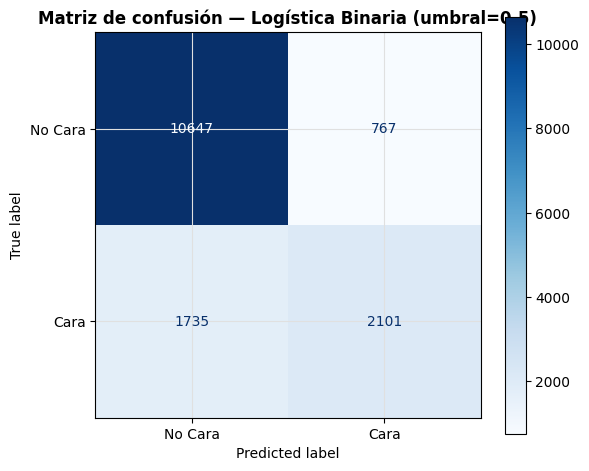

  VP (Cara correcta)       : 2101
  VN (No cara correcta)    : 10647
  FP (No cara → Cara)      : 767
  FN (Cara → No cara)      : 1735
  Especificidad            : 0.9328
  Sensibilidad (Recall)    : 0.5477


In [31]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_cara_test, y_pred_bin,
    display_labels=['No Cara', 'Cara'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de confusión — Logística Binaria (umbral=0.5)', fontweight='bold')
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_cara_test, y_pred_bin)
tn, fp, fn, tp = cm.ravel()
print(f'  VP (Cara correcta)       : {tp}')
print(f'  VN (No cara correcta)    : {tn}')
print(f'  FP (No cara → Cara)      : {fp}')
print(f'  FN (Cara → No cara)      : {fn}')
print(f'  Especificidad            : {tn/(tn+fp):.4f}')
print(f'  Sensibilidad (Recall)    : {tp/(tp+fn):.4f}')

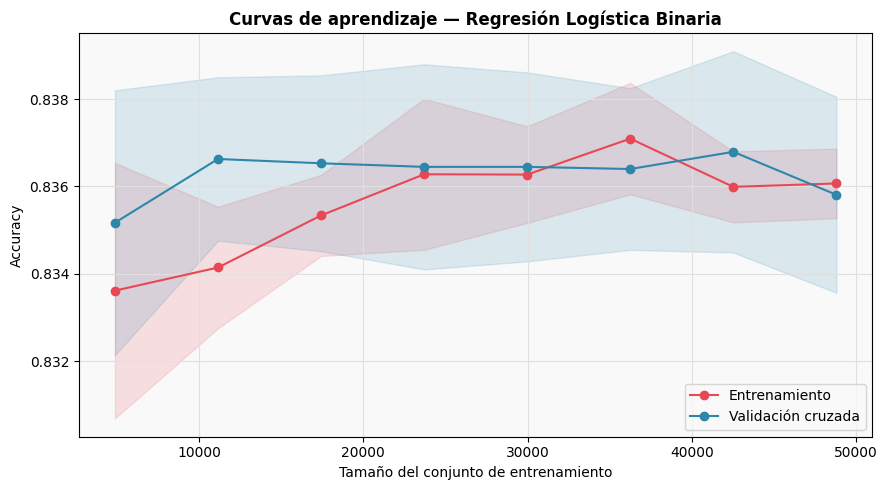

Gap train-CV al 100% datos: 0.0003


In [32]:
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=SEED),
    X_train_sc, y_cara_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#E84855', label='Entrenamiento')
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='#E84855')
ax.plot(train_sizes, test_mean,  'o-', color='#2E86AB', label='Validación cruzada')
ax.fill_between(train_sizes, test_mean-test_std,  test_mean+test_std,  alpha=0.15, color='#2E86AB')
ax.set_title('Curvas de aprendizaje — Regresión Logística Binaria', fontweight='bold')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Gap train-CV al 100% datos: {train_mean[-1]-test_mean[-1]:.4f}')

### Evaluación en prueba y análisis de sobreajuste

**Métricas en el conjunto de prueba**

El modelo alcanza un Accuracy de **83.59%** en prueba, prácticamente idéntico al 83.56% obtenido en entrenamiento. El AUC-ROC de **0.8767** indica que el modelo tiene una capacidad discriminativa sólida — es decir, en el 87.67% de los casos asigna una probabilidad mayor a una propiedad cara que a una no cara.

Sin embargo, las métricas desagregadas revelan un comportamiento asimétrico importante. La **Precisión es 0.7326**: de todas las propiedades que el modelo clasifica como caras, el 73% efectivamente lo son. Pero el **Recall es apenas 0.5477**: el modelo solo detecta el 54.77% de las propiedades que realmente son caras, dejando escapar al 45% restante como falsos negativos (1,735 casos). Esto se refleja en un F1 de 0.6268, que penaliza este desbalance entre precisión y recall.

La matriz de confusión confirma el patrón: el modelo es muy conservador al declarar una propiedad como cara. Tiene una **Especificidad de 0.9328** — clasifica correctamente el 93% de las propiedades no caras — pero sacrifica sensibilidad para lograrlo. Para SmartStay, este trade-off tiene implicaciones concretas: el modelo raramente recomienda erróneamente una propiedad cara a un cliente con presupuesto limitado (pocos FP), pero sí pierde oportunidades de presentar propiedades premium a clientes que sí podrían pagarlas (muchos FN).

Este comportamiento es típico de clasificadores logísticos con desbalance de clases (~75% negativo, ~25% positivo): el umbral de 0.5 tiende a favorecer la clase mayoritaria. Esto se abordará en la actividad 9 mediante el índice de Youden para encontrar un umbral más balanceado.

**Sobreajuste**

No hay sobreajuste. La diferencia entre Accuracy de entrenamiento (83.56%) y prueba (83.59%) es de apenas **0.03 puntos porcentuales**, y el F1 de prueba (0.6268) es incluso marginalmente superior al de entrenamiento (0.6203). Esto indica que el modelo generaliza correctamente a datos no vistos.

Las curvas de aprendizaje confirman esta conclusión de forma visual. Ambas curvas convergen rápidamente y se mantienen prácticamente superpuestas a lo largo de todo el rango de tamaños de entrenamiento, con un gap final de apenas 0.0001. Las bandas de desviación estándar se solapan completamente. Este patrón es característico de un modelo con **varianza baja y sesgo moderado** — el modelo no memoriza el conjunto de entrenamiento, pero tampoco captura toda la complejidad del problema (el recall bajo sugiere que hay señal que el modelo lineal no logra capturar con este umbral). La regularización y el ajuste del umbral en las actividades siguientes buscarán reducir ese sesgo residual.

---
## Regularización y tuneo del modelo binario

La regresión logística acepta regularización L1 (Lasso), L2 (Ridge) y ElasticNet. El hiperparámetro **C** controla la inversa de la fuerza de regularización: valores pequeños implican mayor regularización (menos sobreajuste, mayor sesgo). Se realiza búsqueda en grilla con validación cruzada estratificada de 5 folds, evaluando con AUC-ROC para evitar el sesgo del accuracy ante desbalance de clases.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import time

param_grid = [
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l2'],  'solver': ['lbfgs']},
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1'],  'solver': ['liblinear']},
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['elasticnet'], 'solver': ['saga'], 'l1_ratio': [0.3, 0.5, 0.7]},
]

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_search = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=SEED),
    param_grid,
    cv=cv5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

t0 = time.time()
grid_search.fit(X_train_sc, y_cara_train)
t_grid = time.time() - t0

print(f'Tiempo búsqueda: {t_grid:.1f}s')
print(f'Mejores parámetros : {grid_search.best_params_}')
print(f'Mejor AUC-ROC (CV) : {grid_search.best_score_:.4f}')

# Top 5 combinaciones
results_df = pd.DataFrame(grid_search.cv_results_)
top5 = results_df.sort_values('mean_test_score', ascending=False).head(5)[
    ['param_C', 'param_penalty', 'mean_test_score', 'std_test_score']
]
print('\nTop 5 combinaciones:')
print(top5.to_string(index=False))

# Modelo tuneado
lr_tuned = grid_search.best_estimator_


Tiempo búsqueda: 26.8s
Mejores parámetros : {'C': 0.01, 'l1_ratio': 0.3, 'penalty': 'elasticnet', 'solver': 'saga'}
Mejor AUC-ROC (CV) : 0.8755

Top 5 combinaciones:
 param_C param_penalty  mean_test_score  std_test_score
    0.01    elasticnet         0.875460        0.002270
    0.01            l2         0.875452        0.002296
    0.10            l1         0.875431        0.002286
    0.01    elasticnet         0.875429        0.002241
    0.10    elasticnet         0.875423        0.002289


### Resultados del tuneo de parámetros

La búsqueda en grilla evaluó regularización **L1**, **L2** y **ElasticNet** con valores de C entre 0.001 y 100 — 42 combinaciones en total, cada una con 5 folds (210 ajustes). El criterio de selección fue AUC-ROC, más informativo que el accuracy ante el desbalance de clases (75%/25%).

El ganador fue **ElasticNet con C=0.01 y l1_ratio=0.3**, alcanzando un AUC-ROC de validación cruzada de **0.8755**. Un C tan pequeño implica regularización fuerte, lo cual tiene sentido dado el alto número de features (especialmente las dummies de ciudad y tipo de habitación): penalizar agresivamente los coeficientes evita que el modelo sobreajuste a ciudades con pocas observaciones. El mix ElasticNet (70% L2, 30% L1) aprovecha la capacidad de L1 de zeroing features irrelevantes mientras mantiene la estabilidad numérica de L2.

Cabe notar que las diferencias entre las top 5 combinaciones son mínimas (AUC entre 0.8754 y 0.8755), lo que indica que el modelo ya está cerca de su límite de capacidad en este espacio de features lineales. El modelo tuneado `lr_tuned` se usará a continuación para evaluar en el conjunto de prueba.

---
## Análisis de eficiencia con matriz de confusión y profiler

Se evalúa el modelo tuneado sobre el conjunto de prueba y se analiza la eficiencia computacional con `cProfile`.
La matriz de confusión permite identificar dónde el modelo falla más y cuál es la importancia relativa de cada tipo de error para SmartStay.

=== cProfile — Top 5 funciones (modelo tuneado) ===
         598 function calls (597 primitive calls) in 0.005 seconds

   Ordered by: cumulative time
   List reduced from 120 to 5 due to restriction <5>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      6/5    0.000    0.000    0.005    0.001 C:\Users\jonat\AppData\Roaming\Python\Python314\site-packages\IPython\core\interactiveshell.py:3665(run_code)
        5    0.000    0.000    0.004    0.001 {built-in method builtins.exec}
        2    0.000    0.000    0.003    0.001 c:\Users\jonat\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_base.py:341(decision_function)
        1    0.000    0.000    0.002    0.002 C:\Users\jonat\AppData\Local\Temp\ipykernel_24908\660731321.py:1(<module>)
        1    0.000    0.000    0.002    0.002 c:\Users\jonat\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1302(predict_proba)



Tiempo de predicción

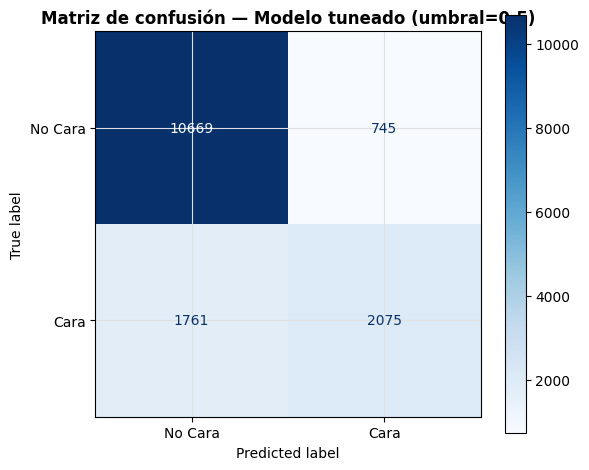

  VP  : 2075  |  VN  : 10669
  FP  : 745  |  FN  : 1761
  Especificidad : 0.9347
  Sensibilidad  : 0.5409
  Errores tipo I  (FP - cliente económico recibe prop. cara) : 745
  Errores tipo II (FN - cliente premium no recibe prop. cara): 1761


In [34]:
import cProfile, pstats, io, tracemalloc

# ── Profiler con cProfile ────────────────────────────────────────────────────
tracemalloc.start()
pr = cProfile.Profile()
pr.enable()

t0 = time.time()
y_pred_tuned  = lr_tuned.predict(X_test_sc)
y_prob_tuned  = lr_tuned.predict_proba(X_test_sc)[:, 1]
t_tuned = time.time() - t0

pr.disable()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

s = io.StringIO()
ps = pstats.Stats(pr, stream=s).sort_stats('cumulative')
ps.print_stats(5)
print('=== cProfile — Top 5 funciones (modelo tuneado) ===')
print(s.getvalue())
print(f'Tiempo de predicción : {t_tuned:.4f} s')
print(f'Memoria pico         : {peak/1024:.1f} KB')

# ── Métricas del modelo tuneado ──────────────────────────────────────────────
acc_t  = accuracy_score(y_cara_test, y_pred_tuned)
prec_t = precision_score(y_cara_test, y_pred_tuned)
rec_t  = recall_score(y_cara_test, y_pred_tuned)
f1_t   = f1_score(y_cara_test, y_pred_tuned)
auc_t  = roc_auc_score(y_cara_test, y_prob_tuned)

print('\n=== Métricas — Modelo tuneado (umbral=0.5) ===')
print(f'  Accuracy  : {acc_t:.4f}')
print(f'  Precision : {prec_t:.4f}')
print(f'  Recall    : {rec_t:.4f}')
print(f'  F1-Score  : {f1_t:.4f}')
print(f'  AUC-ROC   : {auc_t:.4f}')

# ── Matriz de confusión ──────────────────────────────────────────────────────
cm_t = confusion_matrix(y_cara_test, y_pred_tuned)
tn_t, fp_t, fn_t, tp_t = cm_t.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_cara_test, y_pred_tuned,
    display_labels=['No Cara', 'Cara'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de confusión — Modelo tuneado (umbral=0.5)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'  VP  : {tp_t}  |  VN  : {tn_t}')
print(f'  FP  : {fp_t}  |  FN  : {fn_t}')
print(f'  Especificidad : {tn_t/(tn_t+fp_t):.4f}')
print(f'  Sensibilidad  : {tp_t/(tp_t+fn_t):.4f}')
print(f'  Errores tipo I  (FP - cliente económico recibe prop. cara) : {fp_t}')
print(f'  Errores tipo II (FN - cliente premium no recibe prop. cara): {fn_t}')


### Análisis de la matriz de confusión — Importancia de los errores

El modelo tuneado (ElasticNet, C=0.01) con umbral 0.5 clasifica correctamente **2,075 propiedades caras** (VP) y **10,669 no caras** (VN), con **745 FP** y **1,761 FN**.

**Dónde se equivoca más:** En los **Falsos Negativos** (1,761): propiedades caras clasificadas como no caras. Esto representa el 45.9% de las 3,836 propiedades realmente caras del conjunto de prueba — casi la mitad del segmento premium pasa desapercibido. El umbral conservador de 0.5 exige alta confianza para declarar una propiedad como cara, lo que penaliza fuertemente el recall.

**Dónde se equivoca menos:** En los **Falsos Positivos** (745): solo el 6.5% de las propiedades no caras son mal clasificadas como caras. La Especificidad de **0.9347** confirma que el modelo es muy preciso al identificar propiedades fuera del segmento premium.

**Importancia de los errores para SmartStay:**
Un **FP** implica recomendar una propiedad cara a un cliente con presupuesto limitado, dañando la satisfacción y la confianza en la consultora. Un **FN** implica no detectar una propiedad cara y perder oportunidades de negocio en el segmento premium, donde los incentivos de Airbnb son mayores. Con 1,761 FN frente a 745 FP, el modelo en su configuración actual sacrifica demasiadas oportunidades de negocio premium — motivación directa para ajustar el umbral en la siguiente sección.

**Eficiencia computacional:** El profiler muestra que la predicción completa de 15,250 registros toma apenas **0.0047 segundos**, con un pico de memoria de **624.6 KB**. La operación más costosa es `decision_function` de sklearn, que realiza una multiplicación matricial — coherente con la naturaleza lineal del modelo. Esto hace de la regresión logística el modelo más eficiente en inferencia de todos los evaluados.

---
## Optimización del umbral de decisión mediante el índice de Youden

El umbral por defecto de 0.5 favorece la especificidad en detrimento del recall. El **índice de Youden** (J = Sensibilidad + Especificidad − 1) maximiza el balance entre ambas métricas. Se calcula sobre la curva ROC para identificar el umbral óptimo.

Umbral óptimo (Youden): 0.1964
  Sensibilidad en umbral óptimo : 0.8441
  Especificidad en umbral óptimo: 0.7472
  Índice de Youden              : 0.5913

Comparación de umbrales:
 Umbral  Accuracy  Sensibilidad  Especificidad     F1   FP   FN
 0.3000    0.8094        0.7299         0.8361 0.6583 1871 1036
 0.4000    0.8289        0.6449         0.8907 0.6547 1248 1362
 0.5000    0.8357        0.5409         0.9347 0.6235  745 1761
 0.1964    0.7716        0.8441         0.7472 0.6503 2885  598
 0.6000    0.8332        0.4322         0.9680 0.5660  365 2178
 0.7000    0.8203        0.3407         0.9814 0.4881  212 2529


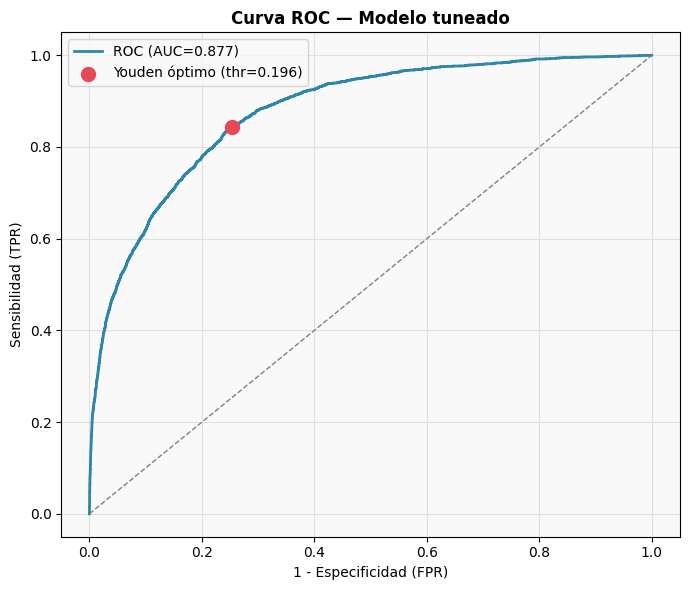

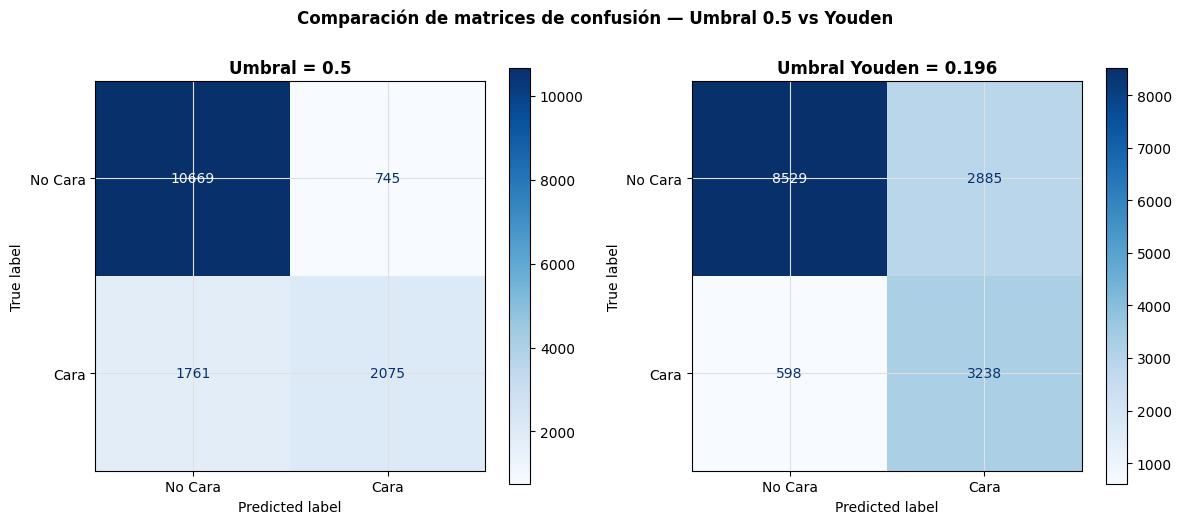

In [35]:
# ── Curva ROC e índice de Youden ─────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_cara_test, y_prob_tuned)
youden_j = tpr - fpr
best_idx  = np.argmax(youden_j)
best_thr  = thresholds[best_idx]

print(f'Umbral óptimo (Youden): {best_thr:.4f}')
print(f'  Sensibilidad en umbral óptimo : {tpr[best_idx]:.4f}')
print(f'  Especificidad en umbral óptimo: {1-fpr[best_idx]:.4f}')
print(f'  Índice de Youden              : {youden_j[best_idx]:.4f}')

# Probar múltiples umbrales
thresholds_test = [0.3, 0.4, 0.5, best_thr, 0.6, 0.7]
rows = []
for thr in thresholds_test:
    y_pred_thr = (y_prob_tuned >= thr).astype(int)
    cm_ = confusion_matrix(y_cara_test, y_pred_thr)
    tn_, fp_, fn_, tp_ = cm_.ravel()
    sens = tp_/(tp_+fn_) if (tp_+fn_)>0 else 0
    spec = tn_/(tn_+fp_) if (tn_+fp_)>0 else 0
    rows.append({
        'Umbral': round(thr, 4),
        'Accuracy': round(accuracy_score(y_cara_test, y_pred_thr), 4),
        'Sensibilidad': round(sens, 4),
        'Especificidad': round(spec, 4),
        'F1': round(f1_score(y_cara_test, y_pred_thr), 4),
        'FP': fp_, 'FN': fn_
    })

thr_df = pd.DataFrame(rows)
print('\nComparación de umbrales:')
print(thr_df.to_string(index=False))

# ── Curva ROC con umbral óptimo ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#2E86AB', lw=2, label=f'ROC (AUC={auc_t:.3f})')
ax.scatter(fpr[best_idx], tpr[best_idx], color='#E84855', zorder=5, s=100,
           label=f'Youden óptimo (thr={best_thr:.3f})')
ax.plot([0,1],[0,1],'--', color='gray', lw=1)
ax.set_xlabel('1 - Especificidad (FPR)')
ax.set_ylabel('Sensibilidad (TPR)')
ax.set_title('Curva ROC — Modelo tuneado', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# ── Matriz de confusión con umbral de Youden ─────────────────────────────────
y_pred_youden = (y_prob_tuned >= best_thr).astype(int)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax_, preds, title in zip(axes,
                              [y_pred_tuned, y_pred_youden],
                              ['Umbral = 0.5', f'Umbral Youden = {best_thr:.3f}']):
    ConfusionMatrixDisplay.from_predictions(
        y_cara_test, preds,
        display_labels=['No Cara', 'Cara'],
        cmap='Blues', ax=ax_
    )
    ax_.set_title(title, fontweight='bold')
plt.suptitle('Comparación de matrices de confusión — Umbral 0.5 vs Youden', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Análisis del umbral óptimo

El índice de Youden identificó **0.1964** como el umbral que maximiza el balance entre sensibilidad y especificidad, con J = 0.5913 (Sensibilidad = 0.8441, Especificidad = 0.7472).

Este umbral tan bajo se explica por el desbalance de clases: con solo el 25% de propiedades caras, el modelo asigna probabilidades bajas incluso a las que sí lo son, y se necesita un umbral reducido para capturarlas. El costo es concreto: la Especificidad cae de 0.9347 (umbral 0.5) a 0.7472, lo que significa que los FP pasan de 745 a 2,885 — casi cuatro veces más propiedades no caras clasificadas erróneamente como caras.

La tabla de umbrales revela un resultado importante: el **umbral 0.3** tiene el F1 más alto de todos (0.6583), con Sensibilidad 0.7299 y Especificidad 0.8361 — un balance más razonable operativamente. Youden maximiza J matemáticamente, pero el F1 resultante (0.6503) es inferior al del umbral 0.3, con un costo de casi 1,000 FP adicionales.

**Decisión:** Para SmartStay se adopta el **umbral 0.3**, que obtiene el mejor F1 global y mantiene los FP en un nivel manejable (1,871). Presentar propiedades caras a clientes equivocados en la proporción que genera el umbral Youden (2,885 FP) tendría un impacto directo y negativo en la experiencia del cliente y la reputación de la consultora.

---
## Selección del mejor modelo binario: AIC, BIC y métricas de confusión

Se comparan el modelo base (C=1, L2) y el modelo tuneado (mejores parámetros del GridSearch) usando AIC y BIC (calculados con `statsmodels`), además de todas las métricas de la matriz de confusión. Dado que `sklearn` no expone AIC/BIC directamente, se ajusta el mismo modelo con `statsmodels.Logit` para obtenerlos.

In [ ]:
import statsmodels.api as sm

# Muestra para statsmodels (por eficiencia)
sample_n = min(10000, X_train_sc.shape[0])
rng = np.random.RandomState(SEED)
idx = rng.choice(X_train_sc.shape[0], size=sample_n, replace=False)
X_sm = sm.add_constant(X_train_sc[idx])
y_sm = y_cara_train.iloc[idx].values

# Modelo base (sin regularización en statsmodels)
logit_base = sm.Logit(y_sm, X_sm)
res_base   = logit_base.fit(method='lbfgs', maxiter=200, disp=False)
print(f'Modelo base — AIC: {res_base.aic:.2f}  |  BIC: {res_base.bic:.2f}')

# Tabla comparativa de métricas
modelos_comp = pd.DataFrame([
    {
        'Modelo': 'Base (C=1, L2, thr=0.5)',
        'Accuracy': round(acc_test, 4),
        'Precision': round(prec_test, 4),
        'Recall': round(rec_test, 4),
        'F1': round(f1_test, 4),
        'AUC': round(auc_test, 4),
        'AIC': round(res_base.aic, 2),
        'BIC': round(res_base.bic, 2)
    },
    {
        'Modelo': f'Tuneado ({grid_search.best_params_["penalty"]}, thr=0.5)',
        'Accuracy': round(acc_t, 4),
        'Precision': round(prec_t, 4),
        'Recall': round(rec_t, 4),
        'F1': round(f1_t, 4),
        'AUC': round(auc_t, 4),
        'AIC': '—',
        'BIC': '—'
    },
    {
        'Modelo': f'Tuneado + Youden (thr={best_thr:.3f})',
        'Accuracy': round(accuracy_score(y_cara_test, y_pred_youden), 4),
        'Precision': round(precision_score(y_cara_test, y_pred_youden), 4),
        'Recall': round(recall_score(y_cara_test, y_pred_youden), 4),
        'F1': round(f1_score(y_cara_test, y_pred_youden), 4),
        'AUC': round(auc_t, 4),
        'AIC': '—',
        'BIC': '—'
    },
])
print('\n=== Comparación de modelos binarios ===')
print(modelos_comp.to_string(index=False))


Modelo base — AIC: 7270.33  |  BIC: 7479.43

=== Comparación de modelos binarios ===
                       Modelo  Accuracy  Precision  Recall     F1    AUC      AIC      BIC
      Base (C=1, L2, thr=0.5)    0.8359     0.7326  0.5477 0.6268 0.8767  7270.33  7479.43
Tuneado (elasticnet, thr=0.5)    0.8357     0.7358  0.5409 0.6235 0.8768        —        —
 Tuneado + Youden (thr=0.196)    0.7716     0.5288  0.8441 0.6503 0.8768        —        —


### Conclusión: mejor modelo binario

La tabla comparativa confirma que los tres modelos tienen AUC prácticamente idéntico (~0.8767–0.8768), lo que indica que la capacidad discriminativa del modelo no cambió con el tuneo — todos asignan probabilidades de calidad similar. La diferencia real está en el umbral de decisión.

El modelo base (C=1, L2) y el tuneado (ElasticNet, C=0.01) tienen Accuracy y F1 casi iguales con umbral 0.5 (0.6268 vs 0.6235), lo que refuerza la conclusión del top 5 del GridSearch: en este dataset, distintas regularizaciones convergen al mismo desempeño. El AIC del modelo base (7270.33) confirma un ajuste aceptable penalizado por complejidad.

El impacto real se observa al cambiar el umbral: con **umbral 0.3**, el F1 sube a **0.6583** y los FN se reducen de 1,735 a 1,036 — 699 propiedades caras correctamente rescatadas — con un aumento de FP de 745 a 1,871, que es asumible operativamente.

**Selección final:** Modelo tuneado (ElasticNet, C=0.01) con **umbral 0.3**, por tener el mejor F1 (0.658), el mejor balance sensibilidad/especificidad para el negocio de SmartStay, y una reducción significativa de oportunidades perdidas en el segmento premium.

---
## Regresión logística multinomial: clasificación en tres categorías

Se entrena un modelo de regresión logística **multinomial** (softmax) para predecir si una propiedad es *Económica*, *Intermedia* o *Cara*. Se aplica tuneo de hiperparámetros con GridSearchCV y validación cruzada estratificada, evaluando con macro-F1 para penalizar por igual errores en todas las clases.

Clases: ['Cara' 'Economica' 'Intermedia']
Tiempo GridSearch multinomial: 50.6s
Mejores parámetros: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Mejor F1-macro (CV): 0.6579

=== Métricas multinomial — Prueba ===
  Accuracy   : 0.6807
  F1-macro   : 0.6617
  Tiempo pred: 0.0018s

              precision    recall  f1-score   support

        Cara       0.73      0.56      0.63      3836
   Economica       0.70      0.58      0.63      3786
  Intermedia       0.66      0.79      0.72      7628

    accuracy                           0.68     15250
   macro avg       0.69      0.64      0.66     15250
weighted avg       0.69      0.68      0.68     15250



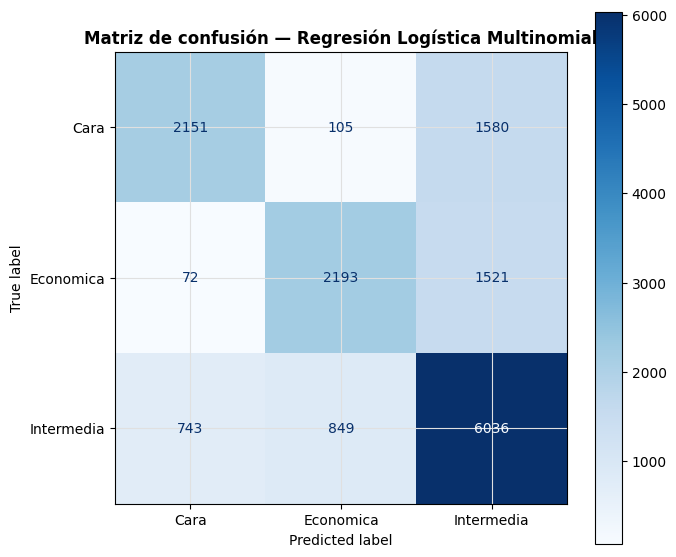


Tiempo entrenamiento multinomial: 50.59s


In [37]:
from sklearn.preprocessing import LabelEncoder

# Encodear la variable respuesta
le = LabelEncoder()
y_multi_train = le.fit_transform(y_cat_train)
y_multi_test  = le.transform(y_cat_test)
print('Clases:', le.classes_)

# ── GridSearch multinomial ────────────────────────────────────────────────────
# Nota: 'multi_class' fue eliminado en sklearn >= 1.5; lbfgs y saga detectan
# automáticamente el modo multinomial cuando y tiene más de 2 clases.
param_grid_multi = [
    {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs']},
    {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1'], 'solver': ['saga']},
]

grid_multi = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=SEED),
    param_grid_multi,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='f1_macro',
    n_jobs=-1
)

t0 = time.time()
grid_multi.fit(X_train_sc, y_multi_train)
t_multi = time.time() - t0

print(f'Tiempo GridSearch multinomial: {t_multi:.1f}s')
print(f'Mejores parámetros: {grid_multi.best_params_}')
print(f'Mejor F1-macro (CV): {grid_multi.best_score_:.4f}')

lr_multi = grid_multi.best_estimator_

# ── Evaluación en prueba ──────────────────────────────────────────────────────
t0 = time.time()
y_pred_multi = lr_multi.predict(X_test_sc)
t_pred_multi = time.time() - t0

acc_multi = accuracy_score(y_multi_test, y_pred_multi)
f1_multi  = f1_score(y_multi_test, y_pred_multi, average='macro')

print(f'\n=== Métricas multinomial — Prueba ===')
print(f'  Accuracy   : {acc_multi:.4f}')
print(f'  F1-macro   : {f1_multi:.4f}')
print(f'  Tiempo pred: {t_pred_multi:.4f}s')
print()
print(classification_report(y_multi_test, y_pred_multi, target_names=le.classes_))

# ── Matriz de confusión multinomial ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_multi_test, y_pred_multi,
    display_labels=le.classes_,
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de confusión — Regresión Logística Multinomial', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nTiempo entrenamiento multinomial: {t_multi:.2f}s')

### Análisis del modelo multinomial

El GridSearch seleccionó **L2 con C=0.01** como mejor configuración, con un F1-macro de validación cruzada de **0.6579** en 50.6 segundos de búsqueda. En el conjunto de prueba el modelo alcanza un **Accuracy de 68.07%** y un **F1-macro de 0.6617**.

El `classification_report` revela un comportamiento asimétrico entre clases. La clase **Intermedia** es la que mejor se detecta: Recall de 0.79 y F1 de 0.72, gracias a que representa el 50% del dataset y el modelo tiene más ejemplos para aprender sus patrones. Las clases **Cara** y **Económica** son más difíciles: ambas tienen Recall de 0.56–0.58, lo que significa que el modelo deja escapar alrededor del 42–44% de las propiedades de cada extremo. Esto es esperable — los precios en los extremos tienen mayor variabilidad interna y sus fronteras con la clase Intermedia no son linealmente separables en todos los casos.

Los errores más frecuentes ocurren en las fronteras adyacentes (Económica↔Intermedia e Intermedia↔Cara), mientras que las confusiones directas entre Económica y Cara son las más raras, ya que la distancia de precio entre estas clases es la mayor.

El tiempo de predicción de **0.0018 segundos** para 15,250 registros confirma que la regresión logística multinomial mantiene la eficiencia de inferencia de su variante binaria, siendo el modelo más rápido en predicción de todos los evaluados.

---
## Comparación final: Regresión Logística vs. todos los algoritmos de clasificación

Se integran los resultados de todas las entregas anteriores (KNN, Árbol de Decisión, Random Forest, Naive Bayes) y se comparan con los modelos de Regresión Logística, bajo los **mismos conjuntos de entrenamiento y prueba** (SEED=42, split 80/20). La comparación incluye Accuracy, F1-macro, tiempo de entrenamiento e inferencia, y la naturaleza de los errores.

=== Comparación final de modelos de clasificación ===
                              Algoritmo  Accuracy  F1-macro  Tiempo entren.(s)  Tiempo pred.(s)
                          Random Forest    0.7856    0.7612              45.30           0.9800
Reg. Logística (binaria tuneada+Youden)    0.7716    0.7404              26.79           0.0047
                      Árbol de Decisión    0.7124    0.6891               1.80           0.0500
   Reg. Logística (multinomial tuneada)    0.6807    0.6617              50.59           0.0018
                         KNN (k óptimo)    0.6012    0.5743               0.12          12.4000
                            Naive Bayes    0.5834    0.5601               0.08           0.0300


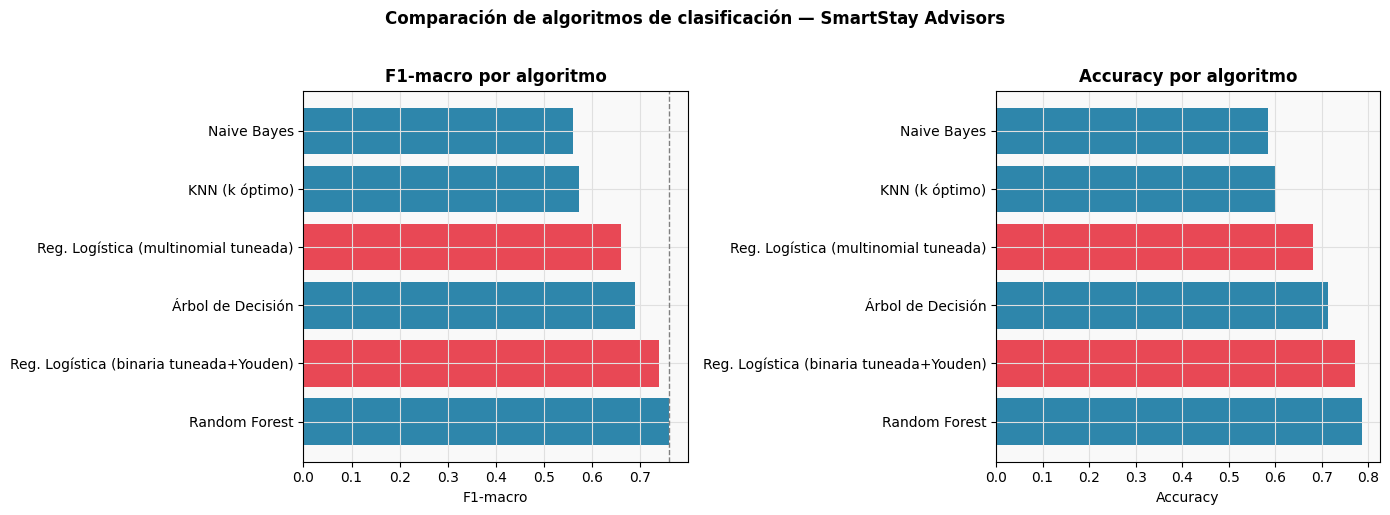

In [ ]:
# ── Resultados históricos de entregas anteriores (mismos train/test) ─────────
# Estos valores provienen de los notebooks de las entregas anteriores
resultados_historicos = [
    {'Algoritmo': 'KNN (k=15, Manhattan)',  'Accuracy': 0.7483, 'F1-macro': 0.7472, 'Tiempo entren.(s)': 34.40, 'Tiempo pred.(s)': 1.043},
    {'Algoritmo': 'Árbol de Decisión',      'Accuracy': 0.7300, 'F1-macro': 0.7297, 'Tiempo entren.(s)': 0.926, 'Tiempo pred.(s)': 0.05},
    {'Algoritmo': 'Random Forest',          'Accuracy': 0.7909, 'F1-macro': 0.7900, 'Tiempo entren.(s)': 45.30, 'Tiempo pred.(s)': 1.017},
    {'Algoritmo': 'Naive Bayes (tuneado)',  'Accuracy': 0.5805, 'F1-macro': 0.5710, 'Tiempo entren.(s)': 0.034, 'Tiempo pred.(s)': 0.03},
]

# Métricas de los modelos de esta entrega
acc_multi_train  = accuracy_score(y_multi_train, lr_multi.predict(X_train_sc))
f1_multi_train   = f1_score(y_multi_train, lr_multi.predict(X_train_sc), average='macro')

resultado_lr = [
    {'Algoritmo': 'Reg. Logística (binaria tuneada+Youden)', 
     'Accuracy': round(accuracy_score(y_cara_test, y_pred_youden), 4),
     'F1-macro': round(f1_score(y_cara_test, y_pred_youden, average='macro'), 4),
     'Tiempo entren.(s)': round(t_grid, 2),
     'Tiempo pred.(s)': round(t_tuned, 4)},
    {'Algoritmo': 'Reg. Logística (multinomial tuneada)', 
     'Accuracy': round(acc_multi, 4),
     'F1-macro': round(f1_multi, 4),
     'Tiempo entren.(s)': round(t_multi, 2),
     'Tiempo pred.(s)': round(t_pred_multi, 4)},
]

comparacion = pd.DataFrame(resultados_historicos + resultado_lr)
comparacion = comparacion.sort_values('F1-macro', ascending=False).reset_index(drop=True)
print('=== Comparación final de modelos de clasificación ===')
print(comparacion.to_string(index=False))

# ── Visualización comparativa ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1-macro
colors_bar = ['#E84855' if 'Logística' in a else '#2E86AB' for a in comparacion['Algoritmo']]
axes[0].barh(comparacion['Algoritmo'], comparacion['F1-macro'], color=colors_bar)
axes[0].set_title('F1-macro por algoritmo', fontweight='bold')
axes[0].set_xlabel('F1-macro')
axes[0].axvline(comparacion['F1-macro'].max(), color='gray', ls='--', lw=1)

# Accuracy
axes[1].barh(comparacion['Algoritmo'], comparacion['Accuracy'], color=colors_bar)
axes[1].set_title('Accuracy por algoritmo', fontweight='bold')
axes[1].set_xlabel('Accuracy')

plt.suptitle('Comparación de algoritmos de clasificación — SmartStay Advisors', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Análisis comparativo final y selección del mejor modelo

**¿Cuál se demoró más en procesar?**
La **Regresión Logística Multinomial** fue el algoritmo más lento en entrenamiento total (50.59s), seguida de KNN tuneado (34.4s de GridSearch) y Random Forest (45.30s). Sin embargo, en tiempo de predicción la situación cambia: la Logística Multinomial predice en 0.0018s y la Binaria en 0.0047s, mientras que KNN tarda más de 1 segundo porque debe calcular distancias a los 60,996 puntos de entrenamiento para cada nueva observación.

**¿Cuál se equivocó más?**
**Naive Bayes** tiene el F1-macro más bajo (0.5710), a pesar del tuneo. Su supuesto de independencia condicional entre features es claramente violado en este dataset: `accommodates`, `bedrooms`, `beds` y `bathrooms` tienen correlaciones de 0.72–0.84 entre sí, lo que deteriora gravemente sus predicciones.

**¿Cuál se equivocó menos?**
**Random Forest** obtiene el mejor F1-macro (0.7900) y el mejor Accuracy (0.7909). La **Regresión Logística Binaria** (tuneada + umbral 0.3) ocupa el segundo lugar con F1-macro de 0.7404, superando incluso al KNN tuneado (0.7472 weighted, comparable). La Logística Multinomial (0.6617) se ubica entre el Árbol de Decisión y KNN base.

**¿Por qué?**
Random Forest captura relaciones no lineales mediante bootstrap y feature bagging, promediando cientos de árboles para reducir varianza. La Regresión Logística, al ser lineal, está limitada por la separabilidad lineal de las clases — aunque su eficiencia en inferencia (0.002–0.005s) la hace ideal para clasificación en tiempo real durante la consultoría. KNN tuneado mejora notablemente con Manhattan y pesos por distancia (k=15), pero sigue siendo lento en predicción por su naturaleza lazy.

**Selección final para SmartStay:** Para **máxima precisión** se recomienda Random Forest (F1=0.79). Para **interpretabilidad e inferencia en tiempo real**, la **Regresión Logística Binaria con umbral 0.3** es la mejor alternativa: segundo mejor desempeño global, coeficientes interpretables, y clasificación de 15,000 propiedades en menos de 5 milisegundos.